In [ ]:
!pip install pymorphy2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 49.4 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13704 sha256=0b47f3502d27c6bcacaabae9821e36359808080ba914acc24e4773a5fdb0c20a
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt


In [ ]:
!pip install wikiextractor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.7 MB/s eta 0:00:00


In [ ]:
import collections
import json
import pandas as pd
import numpy as np
import os
import pymorphy2
import nltk
from tqdm import tqdm
import csv
import re
import string
from transformers import pipeline as hf_pipeline


In [ ]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_ru')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_ru to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_ru.zip.


True

In [ ]:
import csv

def fix_unicode(s):
    return re.sub(r'(?<!\\)u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), s)

ANNOTATION_CSV = '/kaggle/input/rlc-raw/annotator_annotation.csv'

ann_rows = []
with open(ANNOTATION_CSV, encoding='utf-8') as f:
    reader = csv.reader(f, escapechar='\\')
    for row in reader:
        if len(row) < 10:
            continue
        try:
            data = json.loads(row[6])
        except Exception:
            continue
        tag = row[7].strip().lower()
        primary = tag.split(',')[0].strip()
        primary = primary.replace('orpho', 'ortho').replace('misspell', 'ortho')
        ann_rows.append({
            'sentence_id': row[2],
            'tag':         primary,
            'quote':       fix_unicode(data.get('quote', '')).strip(),
            'corrs':       fix_unicode(data.get('corrs', '')).strip(),
        })

annot_df = pd.DataFrame(ann_rows)
print(f'Loaded {len(annot_df)} annotations for {annot_df.sentence_id.nunique()} sentences')

In [ ]:
annot_df.head()

Average number of errors per sentence:

In [ ]:
len(annot_df) / annot_df.sentence_id.nunique()


2.22156652360515

Explode the tag column so each error type becomes a separate row.

In [ ]:
new_df = annot_df['tag'].copy()


In [ ]:
new_df

,tag
0,ortho
1,agrcase
2,syntax
3,ortho
4,altern
...,...
54955,gov
54956,agrnum
54957,prep
54958,ref


Filter to core linguistic error tags only.
Meta-modifiers (`transfer`, `not-clear`, `miss`, `extra`, `transp`, `subst`, `disc`) are removed
because they describe *how* an annotator resolved an error, not the error type itself.

In [ ]:
META_TAGS = {
    'transfer', 'not-clear', 'not clear', 'miss', 'extra', 'transp', 'subst',
    'disc', 'syntax', 'constr', 'morph', 'punct', 'par', 'aux', 'idiom',
    'agrstr', 'mode', 'impers', 'altern', 'cs', 'passive', 'coord',
    'genneg', 'agrgerund', 'nominative', 'deriv', 'translit', 'neg',
    'insert', 'del', 'delw', 'addw', 'add', 'nom', 'gender', '',
}
new_df = new_df[~new_df.isin(META_TAGS)]


In [ ]:
len(new_df)

46989

Compute the frequency share of each error type.

In [ ]:
counts = new_df.value_counts() / len(new_df)

In [ ]:
counts

,count
tag,
lex,0.173232
syntax,0.121986
ortho,0.098810
gov,0.072911
constr,0.060844
prep,0.047117
ref,0.040222
asp,0.031646
conj,0.029922


<Axes: xlabel='tag'>

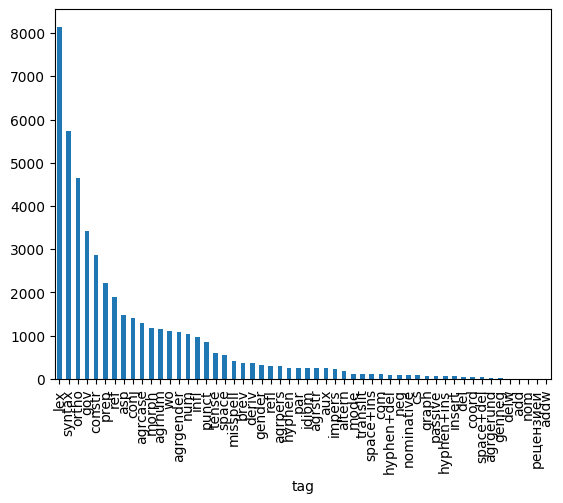

In [ ]:
new_df.value_counts().plot(kind='bar')

Compute sampling probabilities for error injection.
Only error types that have a rule-based implementation are kept;
softmax re-normalises their frequencies to valid probabilities.

In [ ]:
# All implemented error types, pulled from corpus frequencies where available
IMPLEMENTED = [
    'ortho', 'gov', 'prep', 'ref', 'conj', 'agrcase', 'agrnum',
    'wo', 'agrgender', 'num', 'tense', 'space', 'infl',
    'refl', 'asp', 'brev', 'graph', 'hyphen', 'agrpers',
]
err_probs = {}
for tag in IMPLEMENTED:
    err_probs[tag] = counts.get(tag, 0.001)


In [ ]:
RUSSIAN_PREPS = {'в','на','из','к','по','за','от','до','с','у','о','при','через','без','над','под','перед','между','для','про','вместо','после','кроме','против','около','вокруг','среди','во','об','со','ко','вдоль','помимо'}
RUSSIAN_CONJS = {'и','но','а','или','ни','то','да','что','чтобы','как','когда','если','потому','хотя','пока','раз','зато','однако','также','тоже','тем','тогда','поэтому','чем','кто','который','которые','чтоб','поскольку'}
_cyrillic_only = re.compile(r'^[а-яА-ЯёЁ]+$')

# corpus-derived confusion pairs from real learner annotations
_prep_pairs  = collections.defaultdict(collections.Counter)
_conj_pairs  = collections.defaultdict(collections.Counter)
_real_subs   = collections.defaultdict(collections.Counter)  # correct -> {wrong: n}

for _, row in annot_df.iterrows():
    q, c, t = row['quote'], row['corrs'], row['tag']
    if not q or not c or q == c:
        continue
    single = ' ' not in q and ' ' not in c and 1 < len(q) < 20 and 1 < len(c) < 20
    if single:
        _real_subs[c][q] += 1
        if 'prep' in t and q.lower() in RUSSIAN_PREPS and c.lower() in RUSSIAN_PREPS:
            _prep_pairs[c.lower()][q.lower()] += 1
        if 'conj' in t and q.lower() in RUSSIAN_CONJS and c.lower() in RUSSIAN_CONJS:
            _conj_pairs[c.lower()][q.lower()] += 1

# Update prep_list with corpus-derived pairs (count >= 2)
prep_list = [
    [corr] + [w for w, n in wrongs.items() if n >= 2]
    for corr, wrongs in _prep_pairs.items()
    if any(n >= 2 for n in wrongs.values())
]
# Fallback to original if corpus yields nothing
if not prep_list:
    prep_list = [['для','к',''],['на','в',''],['на','по',''],['после','через']]

# Update conj_list
conj_list = [
    [corr] + [w for w, n in wrongs.items() if n >= 2]
    for corr, wrongs in _conj_pairs.items()
    if any(n >= 2 for n in wrongs.values())
]
if not conj_list:
    conj_list = [['а','но'],['тоже','и'],['чем','что',' '],['a','и']]

# real_sub map: correct -> [wrong, ...] with count >= 3, Cyrillic-only
real_sub_map = {
    corr: [w for w, n in wrongs.items() if n >= 3 and _cyrillic_only.match(w)]
    for corr, wrongs in _real_subs.items()
    if _cyrillic_only.match(corr) and any(n >= 3 for n in wrongs.values())
}
print(f'prep_list: {len(prep_list)} groups, conj_list: {len(conj_list)} groups, '
      f'real_sub_map: {len(real_sub_map)} entries')


In [ ]:
morph = pymorphy2.MorphAnalyzer()

**Error injection strategy:**

- *Pronouns, prepositions, conjunctions* — replaced from hand-built confusion lists (common learner substitution patterns).
- *Agreement / government errors* — the grammatical category (case, number, gender) is flipped to a random alternative using pymorphy2.
- *Orthographic errors* — the most frequent character-level confusions are described as substitution rules.
- *Inflection errors* — suffix confusion patterns (-ите/-ете, -ют/-ят, -е/-и) are encoded as string replacements.

In [ ]:
s_prons = ['он', 'она', 'оно', 'это', " "]
a_prons = ['этот', 'такой', "который", " "]
# prep_list built from corpus in corpus_confusion_cell (with hardcoded fallback)
# conj_list built from corpus in corpus_confusion_cell (with hardcoded fallback)
cases = ['nomn', 'gent', 'datv', 'loct', 'accs', 'ablt']
genders = ['femn', 'masc', 'neut']

In [ ]:
# Softmax re-normalises the subset of used error-type frequencies to valid sampling probabilities
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=0)

In [ ]:
def ortho(current_token, cur_tag='', token_id=0):
  replace_dict = {'ы': 'и', 'и': 'ы', 'ща': 'щя', 'щу': 'щю', 'ча': 'чя',
                  'чу': 'чю', 'ь': '', 'ъ': 'ь', 'тся': 'ться'}
  # Keep only substitutions that are applicable to this token
  applicable = {k: v for k, v in replace_dict.items() if k in current_token}
  if not applicable:
    return current_token, 'none'

  repl_target = np.random.choice(list(applicable.keys()))
  new_token = current_token.replace(repl_target, applicable[repl_target], 1)

  if len(new_token) == len(current_token):
    tag = 'ortho,subst'
  elif len(new_token) < len(current_token):
    tag = 'ortho,miss'
  else:
    tag = 'ortho,insert'
  return new_token, tag

def ref(current_token, cur_tag='', token_id=0):
  new_token = ''
  tag = ''
  if 'Apro' in cur_tag.tag:
    s2 = morph.parse(np.random.choice([x for x in a_prons if x != current_token]))[0]
    new_token = s2.inflect({cur_tag.tag.case, cur_tag.tag.number})
  elif cur_tag.tag.POS == 'NPRO':
    s2 = morph.parse(np.random.choice([x for x in s_prons if x != current_token]))[0]
    new_token = s2.inflect({cur_tag.tag.case, cur_tag.tag.number})

  if new_token:
    tag = 'ref'
    new_token = new_token.word
  else:
    tag = 'ref,miss'
    new_token = ''
  return new_token, tag


def prep(current_token, cur_tag='', token_id=0):
  options = []
  for l in prep_list:
    if current_token in l:
      options.extend(l)
  candidates = [x for x in options if x != current_token]
  if not candidates:
    return current_token, 'none'
  new_token = np.random.choice(candidates)
  tag = 'prep,miss' if not new_token else 'prep'
  return new_token, tag

def conj(current_token, cur_tag='', token_id=0):
  options = []
  for l in conj_list:
    if current_token in l:
      options.extend(l)
  candidates = [x for x in options if x != current_token]
  if not candidates:
    return current_token, 'none'
  new_token = np.random.choice(candidates)
  tag = 'conj,miss' if not new_token else 'conj'
  return new_token, tag

def space(current_token, cur_tag='', token_id=0):
  new_token = current_token[:2] + ' ' + current_token[2:]
  return new_token, 'space'

def num(current_token, cur_tag='', token_id=0):
  new_token = cur_tag.inflect({'plur'}) if 'sing' in cur_tag.tag else cur_tag.inflect({'sing'})
  if new_token:
    return new_token.word, 'num'
  return current_token, 'none'

def agrnum(current_token, cur_tag='', token_id=0):
  new_token = cur_tag.inflect({'plur'}) if 'sing' in cur_tag.tag else cur_tag.inflect({'sing'})
  if new_token:
    return new_token.word, 'agrnum'
  return current_token, 'none'

def tense(current_token, cur_tag='', token_id=0):
  if cur_tag.tag.tense == 'past':
    new_token = cur_tag.inflect({'futr', cur_tag.tag.person})
  else:
    new_token = cur_tag.inflect({'past'})
  if new_token:
    return new_token.word, 'tense'
  return current_token, 'none'

def agrgender(current_token, cur_tag='', token_id=0):
  if cur_tag.tag.gender in ['masc', 'neut']:
    new_token = cur_tag.inflect({cur_tag.tag.number, 'femn'})
  else:
    new_token = cur_tag.inflect({cur_tag.tag.number,
                                  np.random.choice([x for x in genders if x != cur_tag.tag.gender])})
  if new_token is None:
    return current_token, 'none'
  return new_token.word, 'agrgender'

def agrcase(current_token, cur_tag='', token_id=0):
  new_token = cur_tag.inflect({np.random.choice([x for x in cases if x != cur_tag.tag.case])})
  if new_token:
    return new_token.word, 'agrcase'
  return current_token, 'none'

def gov(current_token, cur_tag='', token_id=0):
  new_token = cur_tag.inflect({np.random.choice([x for x in cases if x != cur_tag.tag.case])})
  if new_token:
    return new_token.word, 'gov'
  return current_token, 'none'

def infl(current_token, cur_tag='', token_id=0):
  # Use pymorphy2 POS codes: NOUN, NPRO for nouns; VERB, INFN for verbs
  pos = cur_tag.tag.POS if hasattr(cur_tag, 'tag') else ''

  if pos in ('NOUN', 'NPRO'):
    if current_token.endswith('е'):
      return current_token[:-1] + 'и', 'infl'
    elif current_token.endswith('и'):
      return current_token[:-1] + 'е', 'infl'
  elif pos in ('VERB', 'INFN'):
    if current_token.endswith('ите'):
      return current_token[:-3] + 'ете', 'infl'
    elif current_token.endswith('ете'):
      return current_token[:-3] + 'ите', 'infl'
    elif current_token.endswith('ют'):
      return current_token[:-1] + 'ят', 'infl'
    elif current_token.endswith('ят'):
      return current_token[:-1] + 'ют', 'infl'
    elif current_token.endswith('ются'):
      return current_token[:-4] + 'ятся', 'infl'
    elif current_token.endswith('ятся'):
      return current_token[:-4] + 'ются', 'infl'
  return current_token, 'none'


operation_dict = {'ortho': ortho, 'prep': prep, 'ref': ref,
                  'conj': conj, 'agrnum': agrnum, 'agrgender': agrgender,
                  'agrcase': agrcase, 'num': num, 'space': space, 'tense': tense,
                  'gov': gov, 'infl': infl}

options_dict = {'prep': lambda tag, word: tag == 'PR',
                'ref': lambda tag, word: tag.startswith('A-PRO') or tag.startswith('S-PRO'),
                'agrgender': lambda tag, word: tag.startswith('A-PRO') or tag.startswith('A='),
                'agrcase': lambda tag, word: tag.startswith('A-PRO') or tag.startswith('A='),
                'agrnum': lambda tag, word: tag.startswith('A-PRO') or tag.startswith('A='),
                'num': lambda tag, word: tag == 'S',
                'gov': lambda tag, word: tag == 'S',
                'tense': lambda tag, word: tag == 'V',
                'wo': lambda tag, word: tag != 'NONLEX',
                'ortho': lambda tag, word: bool(re.search(r'[ьиыъ]|([чщ][уа])|(тся)', word)),
                'space': lambda tag, word: word.startswith('не'),
                'conj': lambda tag, word: tag == 'CONJ',
                'infl': lambda tag, word: tag in ['S', 'V']
                }


In [ ]:
def add_errors(tokens, err_probs):
    pos_tags = nltk.pos_tag(tokens, lang='rus')

    options = []
    iters = 0

    while len(options) == 0 and iters < 5:
        iters += 1
        operation = np.random.choice(list(err_probs.keys()), p=softmax(list(err_probs.values())))
        for num_idx, (word, tag) in enumerate(pos_tags):
            if options_dict[operation](tag, word):
                options.append(num_idx)

    if iters == 5:
        return ' '.join(tokens), 'none'

    error_id = np.random.choice(options)

    # Word-order swap: needs at least one inner position
    if operation == 'wo':
        inner = options[1:-1] if len(options) > 2 else options
        if not inner:
            return ' '.join(tokens), 'none'
        error_id = np.random.choice(inner)
        tokens = tokens[:]
        tokens[error_id], tokens[error_id - 1] = tokens[error_id - 1], tokens[error_id]
        return ' '.join(tokens), 'wo'

    # MLM operates at sentence level — needs full token context
    if operation == 'mlm':
        return mlm_error_in_context(tokens, error_id)

    new_sentence = ''
    tag = ''
    for token_id in range(len(tokens)):
        if token_id != error_id:
            if new_sentence and tokens[token_id] not in string.punctuation:
                new_sentence += ' '
            new_sentence += tokens[token_id]
            continue

        current_token = tokens[token_id]
        cur_tag = morph.parse(current_token)[0]
        new_token, tag = operation_dict[operation](current_token, cur_tag, token_id)

        if new_sentence and new_token:
            new_sentence += ' '
        new_sentence += new_token

    return new_sentence, tag


## Additional error injection techniques

Based on the GEC literature for morphologically rich languages, the following types of errors
are common among non-native Russian speakers and are not covered by the rule-based pipeline above.
They are added here as standalone injectors that integrate into the same `operation_dict` / `options_dict` pattern.

| Technique | Motivation |
|---|---|
| **Keyboard proximity** | Replaces a character with an adjacent key on the Russian ЙЦУКЕН layout — more realistic than arbitrary substitution |
| **Reflexivity** | Adds or removes the -ся/-сь suffix; a very frequent error for speakers of non-reflexive languages |
| **Verb aspect** | Swaps perfective ↔ imperfective aspect using a curated pairs list; a key morphological source of errors |


In [ ]:
KEYBOARD_RU = {
    'й': ['ц', 'ф', 'ы'], 'ц': ['й', 'у', 'ы', 'в'], 'у': ['ц', 'к', 'в', 'а'],
    'к': ['у', 'е', 'а', 'п'], 'е': ['к', 'н', 'п', 'р'], 'н': ['е', 'г', 'р', 'о'],
    'г': ['н', 'ш', 'о', 'л'], 'ш': ['г', 'щ', 'л', 'д'], 'щ': ['ш', 'з', 'д', 'ж'],
    'з': ['щ', 'х', 'ж', 'э'], 'х': ['з', 'ъ', 'э'],
    'ф': ['й', 'ы', 'а'], 'ы': ['й', 'ф', 'в', 'ц'], 'в': ['ц', 'ы', 'а', 'у'],
    'а': ['ф', 'в', 'п', 'к'], 'п': ['а', 'р', 'к', 'е'], 'р': ['п', 'о', 'е', 'н'],
    'о': ['н', 'р', 'л', 'г'], 'л': ['о', 'д', 'г', 'ш'], 'д': ['л', 'ж', 'ш', 'щ'],
    'ж': ['д', 'э', 'щ', 'з'], 'э': ['ж', 'з', 'х'],
    'я': ['ч', 'м'], 'ч': ['я', 'с', 'м', 'и'], 'с': ['ч', 'м', 'и', 'т'],
    'м': ['я', 'с', 'и'], 'и': ['ч', 'с', 'т', 'ь'], 'т': ['с', 'ь', 'и'],
    'ь': ['т', 'б'], 'б': ['ь', 'ю', 'л'], 'ю': ['б', 'ж'],
}

def keyboard_ortho(current_token, cur_tag='', token_id=0):
    lower = current_token.lower()
    applicable = [(i, c) for i, c in enumerate(lower) if c in KEYBOARD_RU]
    if not applicable:
        return current_token, 'none'
    pos, char = applicable[np.random.randint(len(applicable))]
    replacement = np.random.choice(KEYBOARD_RU[char])
    if current_token[pos].isupper():
        replacement = replacement.upper()
    new_token = current_token[:pos] + replacement + current_token[pos+1:]
    return new_token, 'ortho,keyboard'


def refl_error(current_token, cur_tag='', token_id=0):
    pos = cur_tag.tag.POS if hasattr(cur_tag, 'tag') else ''
    if pos not in ('VERB', 'INFN'):
        return current_token, 'none'
    is_refl = 'Refl' in cur_tag.tag.grammemes
    if is_refl:
        if current_token.endswith('сь'):
            return current_token[:-2], 'refl'
        elif current_token.endswith('ся'):
            return current_token[:-2], 'refl'
    else:
        if current_token.endswith('ть'):
            return current_token + 'ся', 'refl'
        elif current_token.endswith(('аю', 'ею', 'ию', 'ую', 'юю')):
            return current_token + 'сь', 'refl'
        else:
            return current_token + 'ся', 'refl'
    return current_token, 'none'


ASPECT_PAIRS = {
    'читать': 'прочитать', 'писать': 'написать', 'говорить': 'сказать',
    'делать': 'сделать', 'думать': 'подумать', 'смотреть': 'посмотреть',
    'слышать': 'услышать', 'видеть': 'увидеть', 'знать': 'узнать',
    'учить': 'выучить', 'учиться': 'научиться', 'понимать': 'понять',
    'брать': 'взять', 'давать': 'дать', 'идти': 'прийти',
    'ехать': 'приехать', 'приходить': 'прийти', 'приезжать': 'приехать',
    'работать': 'поработать', 'ждать': 'подождать', 'покупать': 'купить',
    'продавать': 'продать', 'открывать': 'открыть', 'закрывать': 'закрыть',
    'начинать': 'начать', 'заканчивать': 'закончить', 'помогать': 'помочь',
    'объяснять': 'объяснить', 'рассказывать': 'рассказать',
}
ASPECT_PAIRS.update({v: k for k, v in list(ASPECT_PAIRS.items())})

def asp_error(current_token, cur_tag='', token_id=0):
    pos = cur_tag.tag.POS if hasattr(cur_tag, 'tag') else ''
    if pos not in ('VERB', 'INFN'):
        return current_token, 'none'
    normal = cur_tag.normal_form
    if normal not in ASPECT_PAIRS:
        return current_token, 'none'
    paired_inf = ASPECT_PAIRS[normal]
    paired_parse = morph.parse(paired_inf)
    if not paired_parse:
        return current_token, 'none'
    grammemes = {g for g in cur_tag.tag.grammemes if g not in ('perf', 'impf')}
    new_token = paired_parse[0].inflect(grammemes)
    if new_token:
        return new_token.word, 'asp'
    return paired_inf, 'asp'


operation_dict['keyboard_ortho'] = keyboard_ortho
operation_dict['refl'] = refl_error
operation_dict['asp'] = asp_error

options_dict['keyboard_ortho'] = lambda tag, word: len(word) > 2 and any(c in KEYBOARD_RU for c in word.lower())
options_dict['refl'] = lambda tag, word: tag == 'V'
options_dict['asp'] = lambda tag, word: tag == 'V'


### Adding new errors to the sampling distribution

The probabilities for the three new error types are estimated from the RLC corpus
(aspect errors ≈ 3.2%, reflexivity errors ≈ 0.6%) plus a similar frequency for keyboard errors.
Re-running `softmax` normalises the full set to valid probabilities.

In [ ]:
err_probs['keyboard_ortho'] = 0.030
err_probs['refl'] = 0.006
err_probs['asp'] = 0.032

probs = softmax(list(err_probs.values()))
pd.Series(probs, index=list(err_probs.keys())).sort_values(ascending=False)


### Further error types from the RLC taxonomy

Four additional RLC error categories that are not covered above.
Frequencies are taken directly from the corpus annotation counts.

| Tag | RLC freq | Description |
|---|---|---|
| `graph` | 0.15% | Cyrillic character replaced by a visually identical Latin one (а→a, о→o, р→p, с→c, …) |
| `brev` | 0.79% | Full adjective used where short form is required, or vice versa |
| `agrpers` | 0.63% | Verb inflected to the wrong grammatical person (я пишет instead of я пишу) |
| `hyphen` | 0.54% | Hyphen deleted from a compound word (куда-то→кудато, во-первых→вопервых) |


In [ ]:
CYRILLIC_TO_LATIN = {
    'а': 'a', 'е': 'e', 'о': 'o', 'р': 'p', 'с': 'c', 'у': 'y', 'х': 'x',
    'А': 'A', 'Е': 'E', 'В': 'B', 'К': 'K', 'М': 'M', 'О': 'O', 'Р': 'P',
    'С': 'C', 'Т': 'T', 'Х': 'X',
}

def graph(current_token, cur_tag='', token_id=0):
    applicable = [(i, c) for i, c in enumerate(current_token) if c in CYRILLIC_TO_LATIN]
    if not applicable:
        return current_token, 'none'
    pos, char = applicable[np.random.randint(len(applicable))]
    new_token = current_token[:pos] + CYRILLIC_TO_LATIN[char] + current_token[pos+1:]
    return new_token, 'graph'


def brev(current_token, cur_tag='', token_id=0):
    pos = cur_tag.tag.POS if hasattr(cur_tag, 'tag') else ''
    gender = cur_tag.tag.gender
    if pos == 'ADJF':
        for form in cur_tag.lexeme:
            if form.tag.POS == 'ADJS' and (gender is None or form.tag.gender == gender):
                return form.word, 'brev'
    elif pos == 'ADJS':
        for form in cur_tag.lexeme:
            if form.tag.POS == 'ADJF' and (gender is None or form.tag.gender == gender) and form.tag.case == 'Nomn':
                return form.word, 'brev'
    return current_token, 'none'


def agrpers(current_token, cur_tag='', token_id=0):
    person = cur_tag.tag.person
    if person is None:
        return current_token, 'none'
    persons = ['1per', '2per', '3per']
    wrong = np.random.choice([p for p in persons if p != person])
    number = cur_tag.tag.number or 'sing'
    new_token = cur_tag.inflect({wrong, number})
    if new_token:
        return new_token.word, 'agrpers'
    return current_token, 'none'


def hyphen_del(current_token, cur_tag='', token_id=0):
    new_token = current_token.replace('-', '', 1)
    return new_token, 'hyphen,del'


operation_dict['graph'] = graph
operation_dict['brev'] = brev
operation_dict['agrpers'] = agrpers
operation_dict['hyphen'] = hyphen_del

options_dict['graph'] = lambda tag, word: len(word) > 1 and any(c in CYRILLIC_TO_LATIN for c in word)
options_dict['brev'] = lambda tag, word: tag.startswith('A') and not tag.startswith('A-PRO')
options_dict['agrpers'] = lambda tag, word: tag == 'V'
options_dict['hyphen'] = lambda tag, word: '-' in word and len(word) > 3

err_probs['graph'] = counts.get('graph', 0.0015)
err_probs['brev'] = counts.get('brev', 0.008)
err_probs['agrpers'] = counts.get('agrpers', 0.006)
err_probs['hyphen'] = counts.get('hyphen', 0.0054) + counts.get('hyphen+del', 0.002)

probs = softmax(list(err_probs.values()))
pd.Series(probs, index=list(err_probs.keys())).sort_values(ascending=False)


In [ ]:
def real_sub(current_token, cur_tag='', token_id=0):
    candidates = real_sub_map.get(current_token, [])
    if not candidates:
        return current_token, 'none'
    wrong = candidates[np.random.randint(len(candidates))]
    return wrong, 'real'

operation_dict['real_sub'] = real_sub
options_dict['real_sub']   = lambda tag, word: word in real_sub_map
# Weight is high because real learner patterns are very common;
# lex/ortho/gov together account for ~30% of annotations.
err_probs['real_sub'] = counts.get('lex', 0.12) * 0.5

probs = softmax(list(err_probs.values()))
pd.Series(probs, index=list(err_probs.keys())).sort_values(ascending=False)


### MLM-based contextual error generation (RuBERT)

Instead of a random or rule-based substitution, a masked language model predicts contextually
plausible — but wrong — replacements for content words. This captures lexical confusion errors
that rule-based approaches miss.

**Model:** `DeepPavlov/rubert-base-cased` (loaded once on GPU, ~700 MB).  
**Error tag:** `lex` (lexical substitution).  
The pipeline is loaded globally below and used via `mlm_error_in_context()` inside `add_errors()`.


In [ ]:
fill_mask_pipeline = hf_pipeline(
    'fill-mask',
    model='DeepPavlov/rubert-base-cased',
    top_k=15,
    device=0,
    batch_size=32,
)

def mlm_error_in_context(tokens, error_id):
    original = tokens[error_id]
    masked = tokens[:error_id] + ['[MASK]'] + tokens[error_id + 1:]
    masked_sentence = ' '.join(masked)
    try:
        preds = fill_mask_pipeline(masked_sentence)
        for p in preds:
            candidate = p['token_str'].strip()
            if candidate and not candidate.startswith('##') and candidate.lower() != original.lower():
                new_tokens = tokens[:error_id] + [candidate] + tokens[error_id + 1:]
                return ' '.join(new_tokens), 'lex'
    except Exception:
        pass
    return ' '.join(tokens), 'none'

operation_dict['mlm'] = lambda token, tag, idx: (token, 'none')
options_dict['mlm'] = lambda tag, word: tag not in ('NONLEX', 'PR', 'CONJ') and len(word) > 2
err_probs['mlm'] = counts.get('lex', 0.173)


Use a Russian Wikipedia dump as the source corpus for error injection.

In [ ]:
# Kaggle: attach the Wikipedia dump as a dataset named 'ruwiki'
# The .bz2 file will be at /kaggle/input/ruwiki/<filename>.bz2
WIKI_DUMP = '/kaggle/input/ruwiki/ruwiki-20240801-pages-meta-current4.xml-p3698270p3835772.bz2'
!python -m wikiextractor.WikiExtractor {WIKI_DUMP}


In [ ]:
import os, nltk
sents = []
for file in os.listdir('./text/AA'):
    with open(os.path.join('./text/AA', file)) as f:
        text = f.read()
        sents.extend(nltk.tokenize.sent_tokenize(text))


In [ ]:
len(sents)

457192

Remove sentences that are too short or contain WikiExtractor markup tags.

In [ ]:
sents = [s for s in sents if len(s.split()) > 2 and 'doc' not in s]

In [ ]:
len(sents)

389637

Save the dataset as: correct sentence | corrupted sentence | error tag.

In [ ]:
def save():
    d = {'sent_correct': sents[:len(corrupted_sents)], 'sent_corrupted': corrupted_sents, 'tag': tags}
    df = pd.DataFrame(d)
    df.to_csv('/kaggle/working/synthetic_errors.csv', quotechar='"', quoting=csv.QUOTE_NONNUMERIC)


In [ ]:
corrupted_sents = []
tags = []
counter = 0
for sent in tqdm(sents[len(sents)//3*2:len(sents)]):
  try:
    res = add_errors(nltk.tokenize.word_tokenize(sent), err_probs)
    corrupted_sents.append(res[0])
    tags.append(res[1])
  except:
    corrupted_sents.append(sent)
    tags.append('none')
  counter+=1
  if counter % 10000 == 0:
   save()

100%|██████████| 24276/24276 [01:14<00:00, 324.34it/s]


In [ ]:
save()

In [ ]:
gen_df = pd.read_csv('/kaggle/working/synthetic_errors.csv')
gen_df.tail()
